In [1]:
import torch
import numpy as np


In [3]:
file_dir = r"D:\研三\大山1-毕业论文\代码\v41_data\pressure_data_3.npy"
data_np = np.load(file_dir)
data_np = torch.from_numpy(data_np).float()
print(data_np.shape)

torch.Size([1001, 41, 41])


In [4]:
global_max = data_np.max()
global_min = data_np.min()
data_normalized = (data_np - global_min) /(global_max - global_min)
data_input = data_normalized.unsqueeze(1)

In [7]:
import numpy as np

data_39 = data_normalized[:, 1:-1, 1:-1]

# 2. 稀疏采样为 20×20
data_20 = data_39[:, ::2, ::2]

print("原始形状:", data_normalized.shape)
print("去边后形状:", data_39.shape)
print("稀疏后形状:", data_20.shape)

原始形状: torch.Size([1001, 41, 41])
去边后形状: torch.Size([1001, 39, 39])
稀疏后形状: torch.Size([1001, 20, 20])


Image 805:
Min Value: 0.2877907156944275
Image 841:
Min Value: 0.2562984824180603
Image 867:
Min Value: 0.23352715373039246
Image 217:
Min Value: 0.8062015771865845
Image 467:
Min Value: 0.5857558250427246


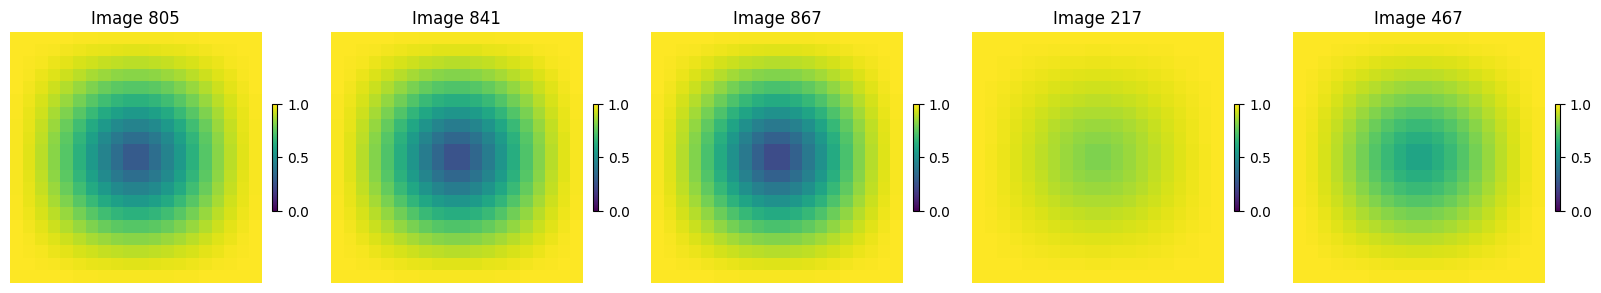

In [ ]:
import matplotlib.pyplot as plt
import random
random_indices = random.sample(range(data_20.shape[0]), 5)

# 创建一个1x10的图像展示
fig, axes = plt.subplots(1, 5, figsize=(20, 4))  # 设置图像大小为20x4，方便查看
fig.subplots_adjust(wspace=0.2)  # 调整每个子图之间的间距

# 打印每张图片的最大值及其位置，并显示图片
for i, idx in enumerate(random_indices):
    image = data_20[idx]  # 获取第idx张图片

    # 获取最大值及其位置
    min_val = torch.min(image)


    # 打印图片的最大值及其位置
    print(f"Image {idx+1}:")
    print(f"Min Value: {min_val}")

    # 在对应的子图中显示图片，并设置颜色条范围为 [0, 1]
    im = axes[i].imshow(image, cmap='viridis', vmin=0, vmax=1)  # 使用 'viridis' 色图，设置颜色条范围为 [0, 1]
This part of the code is responsible for customizing and displaying the images in a subplot grid. Here's a breakdown of each step:
    axes[i].set_title(f"Image {idx+1}")
    axes[i].axis('off')  # 关闭坐标轴

    # 添加颜色条
    plt.colorbar(im, ax=axes[i], fraction=0.02, pad=0.04)  # 添加颜色条，确保颜色条在 [0, 1] 范围内

# 显示所有图片
plt.show()

Image 958:
Min Value: 0.15310080349445343
Image 505:
Min Value: 0.5523256063461304
Image 309:
Min Value: 0.7252907156944275
Image 663:
Min Value: 0.41327521204948425
Image 304:
Min Value: 0.729651153087616


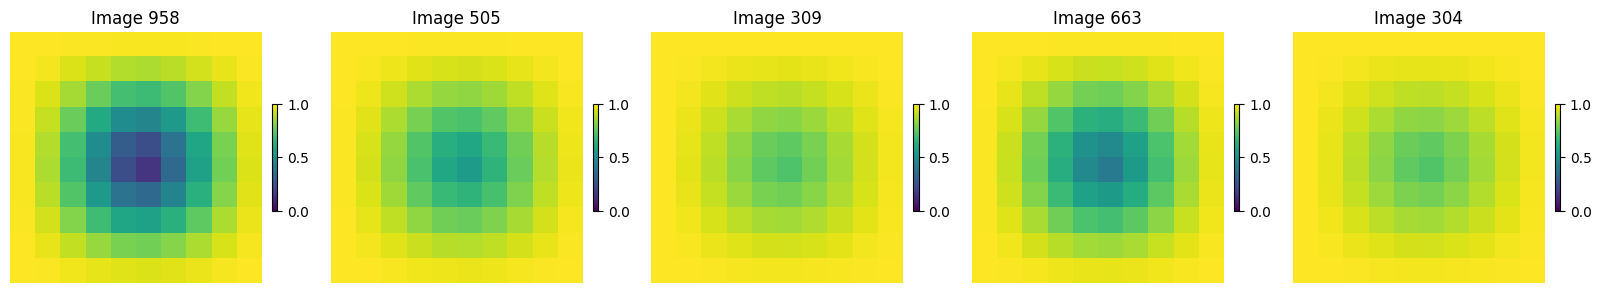

In [11]:
data_10 = data_20[:, ::2, ::2]
random_indices = random.sample(range(data_10.shape[0]), 5)

# 创建一个1x10的图像展示
fig, axes = plt.subplots(1, 5, figsize=(20, 4))  # 设置图像大小为20x4，方便查看
fig.subplots_adjust(wspace=0.2)  # 调整每个子图之间的间距

# 打印每张图片的最大值及其位置，并显示图片
for i, idx in enumerate(random_indices):
    image = data_10[idx]  # 获取第idx张图片

    # 获取最大值及其位置
    min_val = torch.min(image)


    # 打印图片的最大值及其位置
    print(f"Image {idx+1}:")
    print(f"Min Value: {min_val}")

    # 在对应的子图中显示图片，并设置颜色条范围为 [0, 1]
    im = axes[i].imshow(image, cmap='viridis', vmin=0, vmax=1)  # 使用 'viridis' 色图，设置颜色条范围为 [0, 1]

    axes[i].set_title(f"Image {idx+1}")
    axes[i].axis('off')  # 关闭坐标轴

    # 添加颜色条
    plt.colorbar(im, ax=axes[i], fraction=0.02, pad=0.04)  # 添加颜色条，确保颜色条在 [0, 1] 范围内

# 显示所有图片
plt.show()

C:\Users\17710\AppData\Local\Temp\ipykernel_28908\367708991.py:42: UserWarning: Glyph 25512 (\N{CJK UNIFIED IDEOGRAPH-63A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\17710\AppData\Local\Temp\ipykernel_28908\367708991.py:42: UserWarning: Glyph 33616 (\N{CJK UNIFIED IDEOGRAPH-8350}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


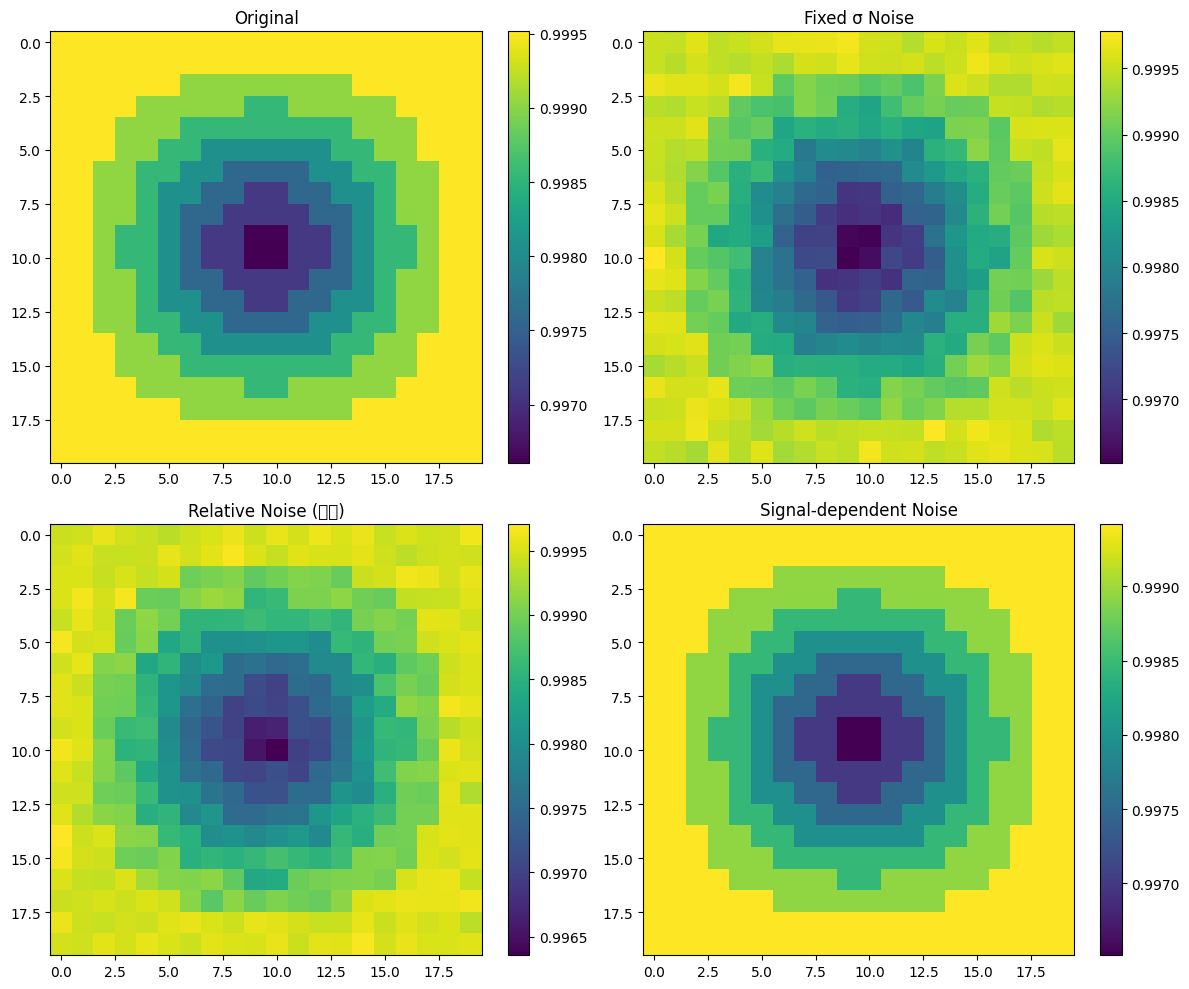

In [30]:
def noise_fixed_sigma(data, sigma=0.0001):
    noise = np.random.normal(0, sigma, size=data.shape)
    return data + noise

def noise_relative(data, noise_level=1e5):
    sigma = noise_level * np.max(np.std(data))
    noise = np.random.normal(0, sigma, size=data.shape)
    return data + noise

def noise_signal_dependent(data, noise_level=5e5):
    noise = np.random.normal(0, noise_level * np.std(data))
    return data + noise

# ====== 选一张图 ======
idx = 0
img = data_20[idx]
img = img.cpu().numpy()

# ====== 加噪声 ======
img_fixed = noise_fixed_sigma(img, sigma=0.0001)
img_relative = noise_relative(img, noise_level=0.1)
img_signal = noise_signal_dependent(img, noise_level=0.5)

# ====== 画图 ======
plt.figure(figsize=(12, 10))

titles = [
    "Original",
    "Fixed σ Noise",
    "Relative Noise (推荐)",
    "Signal-dependent Noise"
]

images = [img, img_fixed, img_relative, img_signal]

for i in range(4):
    plt.subplot(2, 2, i+1)
    im = plt.imshow(images[i], cmap='viridis')
    plt.title(titles[i], fontsize=12)
    plt.colorbar(im, fraction=0.046)

plt.tight_layout()
plt.show()

In [33]:
data_noise = noise_fixed_sigma(data_20, sigma=0.001)

C:\Users\17710\AppData\Local\Temp\ipykernel_28908\367708991.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return data + noise


C:\Users\17710\AppData\Local\Temp\ipykernel_28908\367708991.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return data + noise


Image 77:
Min Value: 0.9193262922885996
Image 796:
Min Value: 0.2901334117396445
Image 192:
Min Value: 0.817786905675959
Image 214:
Min Value: 0.7898139417740137
Image 494:
Min Value: 0.5508830414982003


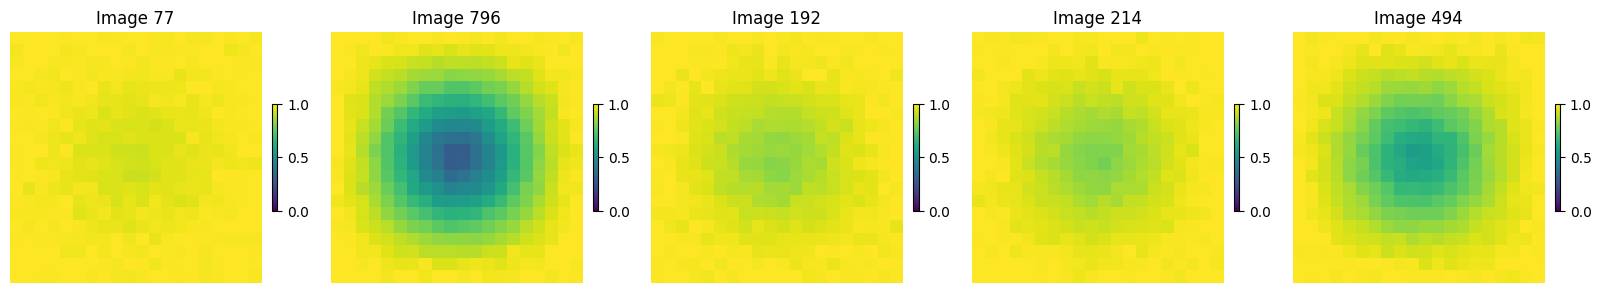

In [40]:
data_noise = noise_fixed_sigma(data_20, sigma=0.01)
random_indices = random.sample(range(data_noise.shape[0]), 5)

# 创建一个1x10的图像展示
fig, axes = plt.subplots(1, 5, figsize=(20, 4))  # 设置图像大小为20x4，方便查看
fig.subplots_adjust(wspace=0.2)  # 调整每个子图之间的间距

# 打印每张图片的最大值及其位置，并显示图片
for i, idx in enumerate(random_indices):
    image = data_noise[idx]  # 获取第idx张图片

    # 获取最大值及其位置
    min_val = torch.min(image)


    # 打印图片的最大值及其位置
    print(f"Image {idx+1}:")
    print(f"Min Value: {min_val}")

    # 在对应的子图中显示图片，并设置颜色条范围为 [0, 1]
    im = axes[i].imshow(image, cmap='viridis', vmin=0, vmax=1)  # 使用 'viridis' 色图，设置颜色条范围为 [0, 1]

    axes[i].set_title(f"Image {idx+1}")
    axes[i].axis('off')  # 关闭坐标轴

    # 添加颜色条
    plt.colorbar(im, ax=axes[i], fraction=0.02, pad=0.04)  # 添加颜色条，确保颜色条在 [0, 1] 范围内

# 显示所有图片
plt.show()

In [41]:
np.save('data_noise_0.1.npy', data_noise)